[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatheusSilveiraVicente/case-especialista-dados/blob/main/notebooks/04_demo_clip.ipynb)

# Mini demo CLIP com banners sintéticos

Esta demonstração usa apenas imagens geradas por código. Ela apresenta embeddings, classificação zero-shot e agrupamento visual; não usa banners reais nem mede performance comercial.

## Preparação reproduzível

No Google Colab, a célula instala as dependências e gera 32 banners 800×300 com gabarito conhecido. Execute o notebook a partir da raiz do repositório para que `src` esteja disponível.

In [1]:
# Setup: roda localmente ou no Google Colab
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "MatheusSilveiraVicente/case-especialista-dados"

if IN_COLAB:
    pasta = Path("/content/case-especialista-dados")
    if not pasta.exists():
        url = f"https://github.com/{REPO}.git"
        try:  # repositório privado: crie o segredo GITHUB_TOKEN (somente leitura) no painel de chaves do Colab
            from google.colab import userdata
            url = f"https://{userdata.get('GITHUB_TOKEN')}@github.com/{REPO}.git"
        except Exception:
            pass
        subprocess.run(["git", "clone", "-q", url, str(pasta)], check=True, capture_output=True)
    os.chdir(pasta)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers", "pillow", "scikit-learn"], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Ambiente:", "Colab" if IN_COLAB else "local")

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image as IPyImage, display

from src.clip_demo import (
    ROTULOS_ZERO_SHOT, avaliar_zero_shot, clusters, composicao_clusters,
    embeddings, gerar_banners, plotar_mapa_2d, plotar_vizinhos,
    vizinhos, zero_shot,
)

SEED = 42
np.random.seed(SEED)
pasta = Path("data/banners_sinteticos")
gabarito = gerar_banners(pasta, n=32, seed=SEED)
caminhos = [pasta / nome for nome in gabarito["arquivo"]]
display(gabarito.head())

Ambiente: local


,arquivo,fundo,cor_dominante,mensagem,preco_visivel,elemento_produto
0,banner_547345cae1.png,escuro,dourado,lançamento,não,sim
1,banner_03ddf85112.png,claro,azul,lançamento,não,sim
2,banner_cdf56f9773.png,escuro,rosa,lançamento,não,não
3,banner_9943b4bc88.png,claro,dourado,lançamento,não,não
4,banner_720b4b48fe.png,claro,dourado,lançamento,sim,sim


## Embeddings: a impressão digital da imagem

O CLIP transforma cada banner em um vetor numérico normalizado — uma "impressão digital da imagem". Imagens e textos semanticamente próximos ficam perto no mesmo espaço. O modelo roda em CPU nesta demo.

In [2]:
import time
from src.clip_demo import carregar_modelo, dispositivo
carregar_modelo()  # download/carga fora da medição
inicio = time.perf_counter()
emb = embeddings(caminhos)
duracao = time.perf_counter() - inicio
print(f"Dispositivo: {dispositivo().upper()} | {len(caminhos)} banners em {duracao:.2f} s ({duracao / len(caminhos) * 1000:.0f} ms por banner)")
print(f"Matriz de embeddings: {emb.shape}")
print(f"Norma média: {np.linalg.norm(emb, axis=1).mean():.4f}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Dispositivo: CPU | 32 banners em 2.31 s (72 ms por banner)
Matriz de embeddings: (32, 512)
Norma média: 1.0000


## Atributos por zero-shot

Prompts em inglês descrevem as classes possíveis. Não há treino com o gabarito: o CLIP escolhe o texto mais próximo e produz uma probabilidade relativa. A tabela de erros mostra objetivamente o que o zero-shot acertou e errou.

In [3]:
previsto = zero_shot(emb, ROTULOS_ZERO_SHOT)
acuracia = avaliar_zero_shot(previsto, gabarito)
Path("reports/metrics").mkdir(parents=True, exist_ok=True)
acuracia.to_csv("reports/metrics/clip_zero_shot_acuracia.csv", index=False)
display(acuracia.style.format({"acuracia": "{:.1%}"}))

erros = []
for atributo in ROTULOS_ZERO_SHOT:
    mascara = previsto[atributo].ne(gabarito[atributo])
    parte = pd.DataFrame({
        "arquivo": gabarito.loc[mascara, "arquivo"],
        "atributo": atributo,
        "real": gabarito.loc[mascara, atributo],
        "previsto": previsto.loc[mascara, atributo],
        "probabilidade": previsto.loc[mascara, f"{atributo}_probabilidade"],
    })
    erros.append(parte)
erros = pd.concat(erros, ignore_index=True)
display(erros.head(12) if len(erros) else "Nenhum erro nesta amostra.")

,atributo,acuracia,n
0,fundo,56.2%,32
1,cor_dominante,100.0%,32
2,mensagem,31.2%,32
3,preco_visivel,50.0%,32
4,elemento_produto,50.0%,32


,arquivo,atributo,real,previsto,probabilidade
0,banner_03ddf85112.png,fundo,claro,escuro,0.642134
1,banner_9943b4bc88.png,fundo,claro,escuro,0.741434
2,banner_720b4b48fe.png,fundo,claro,escuro,0.699867
3,banner_7cbaf57b7f.png,fundo,claro,escuro,0.670107
4,banner_79f30f0a5a.png,fundo,claro,escuro,0.661988
5,banner_fbf02f4bb0.png,fundo,claro,escuro,0.876924
6,banner_b47dfaa3e4.png,fundo,claro,escuro,0.817114
7,banner_c0b7909ba5.png,fundo,claro,escuro,0.644701
8,banner_5cbc838105.png,fundo,claro,escuro,0.596231
9,banner_de036ece6a.png,fundo,claro,escuro,0.817114


## Agrupamento de estilos visuais

O k-means cria quatro grupos sem consultar o gabarito. A composição abaixo revela se os clusters separam fundo, cor, tipo de mensagem, preço ou elemento de produto. PCA serve apenas para visualizar esse espaço em duas dimensões.

,cluster,atributo,valor,quantidade,proporcao
8,0,cor_dominante,azul,2,0.250
9,0,cor_dominante,dourado,2,0.250
10,0,cor_dominante,rosa,2,0.250
11,0,cor_dominante,verde,2,0.250
36,0,elemento_produto,não,4,0.500
37,0,elemento_produto,sim,4,0.500
0,0,fundo,claro,4,0.500
1,0,fundo,escuro,4,0.500
24,0,mensagem,lançamento,8,1.000
28,0,preco_visivel,não,4,0.500


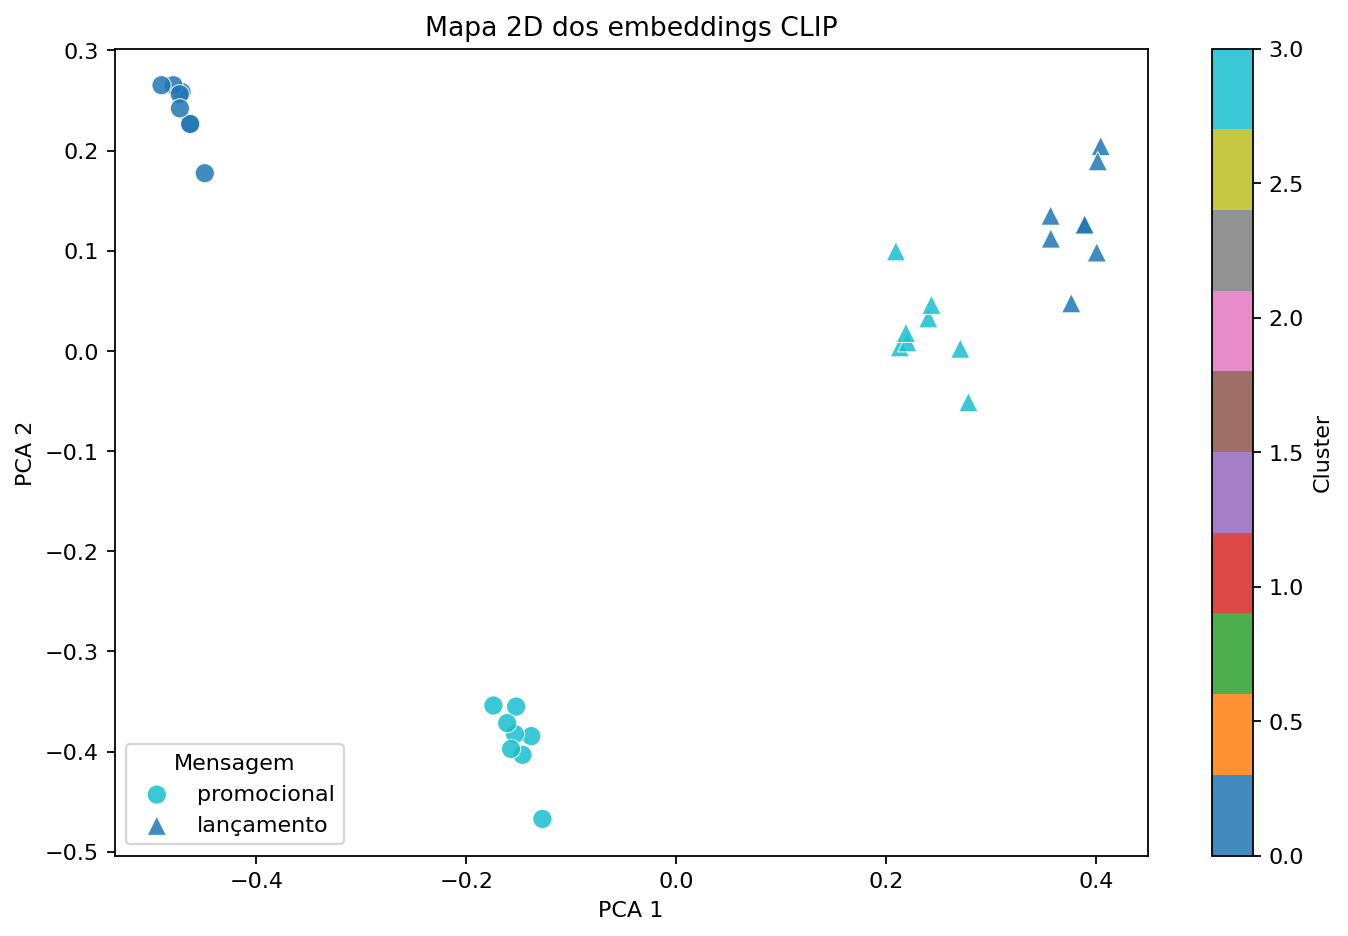

In [4]:
rotulos_cluster = clusters(emb, k=4, seed=SEED)
composicao = composicao_clusters(rotulos_cluster, gabarito)
composicao.to_csv("reports/metrics/clip_clusters.csv", index=False)
display(composicao.sort_values(["cluster", "atributo", "proporcao"], ascending=[True, True, False]))
plotar_mapa_2d(emb, rotulos_cluster, gabarito)
display(IPyImage(filename="reports/figures/clip_mapa_2d.png"))

## Poucos exemplos rotulados resolvem? (linear probe)

O zero-shot depende de o texto da pergunta casar com a imagem. Aqui simulamos o cenário do MVP: o time de negócio rotula uma amostra pequena e um classificador simples (regressão logística) aprende sobre os embeddings. Validação cruzada em 4 partes: 24 banners para treinar, 8 para testar, a cada rodada.

In [5]:
from src.clip_demo import linear_probe
probe = linear_probe(emb, gabarito, folds=4, seed=SEED)
probe.to_csv("reports/metrics/clip_linear_probe.csv", index=False)
comparativo = acuracia.merge(probe, on="atributo", suffixes=("_zero_shot", "_linear_probe"))
display(comparativo[["atributo", "acuracia_zero_shot", "acuracia_linear_probe"]])

,atributo,acuracia_zero_shot,acuracia_linear_probe
0,fundo,0.5625,0.65625
1,cor_dominante,1.0000,0.93750
2,mensagem,0.3125,1.00000
3,preco_visivel,0.5000,0.18750
4,elemento_produto,0.5000,0.25000


**Leitura**
- **O que é grande e dominante está no embedding:** cor e tipo de mensagem. Os clusters separam promoção de lançamento sem nenhum rótulo, e com 24 exemplos o classificador acerta 100%.
- **O zero-shot errou a mensagem pela pergunta, não pela imagem:** prompts em inglês não casam com "50% OFF" e "NOVO". Rotular uma amostra pequena corrige isso; é o papel do time do hackathon no MVP.
- **Detalhes pequenos (preço, frasco) não aparecem no embedding global:** para eles a arquitetura prevê OCR e atributos quantitativos. O embedding sozinho não basta.
- **Por que 19% e 25%, abaixo do acaso (50%)?** Quando não há sinal, a validação cruzada com poucos exemplos tende a ficar abaixo do acaso: ao retirar exemplos de uma classe para o teste, o treino fica levemente enviesado para a outra. Leia esses números como "atributo não detectado", não como "anti-sinal".
- **Banners em português:** o CLIP original foi treinado com legendas em inglês. Para zero-shot com texto em português, usar uma versão multilíngue (por exemplo, CLIP multilíngue ou SigLIP multilíngue) ou rotular uma amostra, como acima.

## Busca por vizinhos

A similaridade de cosseno recupera os três banners mais próximos da consulta. É o equivalente simples ao índice FAISS proposto para o MVP, adequado ao pequeno volume da demonstração.

Consulta e vizinhos: [0, 25, 9, 23]


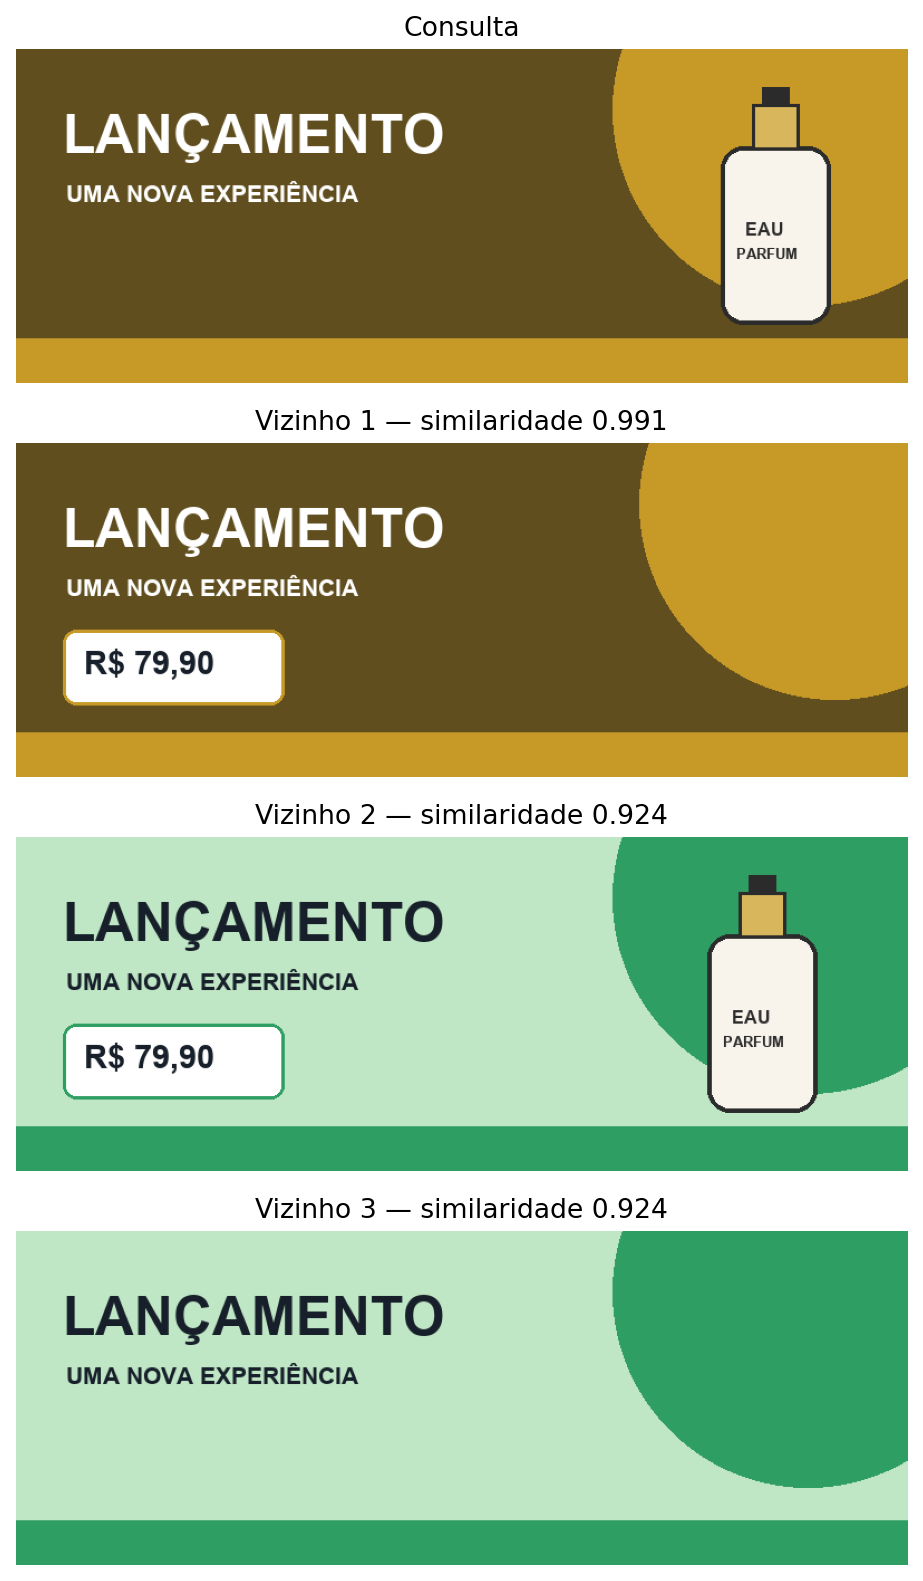

In [6]:
indices = vizinhos(emb, i=0, k=4)
print("Consulta e vizinhos:", indices.tolist())
plotar_vizinhos(caminhos, emb, i=0, k=3)
display(IPyImage(filename="reports/figures/clip_vizinhos.png"))

## Pasta opcional de banners reais

Se imagens autorizadas forem colocadas manualmente em `data/banners_reais/`, a célula aplica embeddings, zero-shot, clusters e vizinhos sem gabarito. Nenhuma imagem é baixada da internet.

In [7]:
pasta_reais = Path("data/banners_reais")
imagens_reais = sorted(pasta_reais.glob("*.png")) if pasta_reais.exists() else []
if imagens_reais:
    emb_reais = embeddings(imagens_reais)
    previsto_reais = zero_shot(emb_reais, ROTULOS_ZERO_SHOT)
    previsto_reais.insert(0, "arquivo", [p.name for p in imagens_reais])
    previsto_reais.to_csv("reports/metrics/clip_reais_zero_shot.csv", index=False)
    grupos_reais = clusters(emb_reais, k=min(4, len(imagens_reais)), seed=SEED)
    pd.DataFrame({"arquivo": [p.name for p in imagens_reais], "cluster": grupos_reais}).to_csv(
        "reports/metrics/clip_reais_clusters.csv", index=False
    )
    plotar_vizinhos(imagens_reais, emb_reais, i=0, k=min(3, len(imagens_reais) - 1),
                     saida="reports/figures/clip_reais_vizinhos.png")
    display(previsto_reais.head())
else:
    print("Pasta opcional ausente ou sem PNGs; etapa ignorada.")

Pasta opcional ausente ou sem PNGs; etapa ignorada.


## Limite da demonstração

Esta demo valida componentes técnicos e permite inspecionar semântica e estilo. Como não existe KPI de performance (CTR, conversão ou receita) associado às imagens, **isto não é um score de CTR** e não permite afirmar que um banner venderá mais. Esse aprendizado exige dados históricos controlados e validação posterior em teste A/B.